# Progetto Sistemi Complessi
- **Dino Meng** [SM3201466]

*Dichiaro che l'intero progetto è svolto autonomamente*

---

## Parte 1: Modello e Risultati Principali

Siano $x(t), y(t)$ rispettivamente le *population size* delle popolazioni di *prede* e *predatori*. Generalmente, per descrivere una dinamica del genere si usa la seguente DE:

$$
\begin{cases}
\dot x = \rho_x (x,y)x \\
\dot y = \rho_y (x,y)y
\end{cases}
$$



Il paper [*"Effect of the Fear Factor and Prey Refuge in an Asymmetric Predator–Prey Model"*](./s13538-024-01594-9.pdf) di Rasha M., May M., D. Kaushik e Ahmed A. descrive una dinamica di popolazioni prede-predatori tenendo conto dei seguenti fattori aggiuntivi:

> H1: La popolazione delle prede cresce come una popolazione logistica in assenza dei predatori

> H2: La presenza dei predatori inducono paura nelle prede, portando ad una decrescita nel tasso di natalità delle prede per lo stress cognitivo, come può anche aumentare il tasso di mortalità delle prede

> H3: La risposta funzionale dei predatori alle prede è di tipo asimmetrico

> H4: Uno dei fattori naturali è la migrazione delle prede quando c'è una lacuna di cibo (prede o un'altra fonte di cibo)

*N.B. I passaggi H1, H2, H3, H4 sono tradotti direttamente dal paper di riferimento.*

> H5: Le prede e i predatori competono per le stesse risorse

*N.B. ho aggiunto H5 per rendere più chiaro il modello, in quanto non era specificato la condivisione della risorse*

Pertanto si ottiene il seguente modello:

$$
\left\{
\begin{align*}
& \dot x = x\left[\frac{r}{1+fy}-\frac{\beta(1-m)y}{\psi y + \alpha \theta + (1-m)x}- a(1+fy)-kx\right] \\
& \dot y = y\left[e\frac{\beta(1-m)x}{\psi y + \alpha \theta + (1-m)x} - d -\frac{\sigma}{(1-m)x+\alpha\theta}-\varepsilon y\right]
\end{align*}
\right.
$$

I parametri sono descritti nella seguente tabella.

| **Parametro**    | **Significato**                                                                     |
|------------------|-------------------------------------------------------------------------------------|
| $r$              | Tasso di crescita delle prede                                                       |
| $\beta$          | Tasso di predazione                                                                 |
| $e$              | Tasso di conversione del consumo delle prede da parte dei predatori                 |
| $k, \varepsilon$ | Tassi di competizione per le risorse (rispettivamente "esercitate da" $y$ e di $x$) |
| $f$              | Tasso di paura delle prede                                                          |
| $m$              | Tasso di rifugio delle prede                                                        |
| $\alpha \theta$  | Quantità e qualità delle risorse aggiuntive                                         |
| $a, d$           | Tassi di mortalità (rispettivamente di $x,y$)                                       |
| $\sigma$         | Tasso di migrazione dei predatori                                                   |
| $\psi$           | Costante di saturazione della predazione                                            |

*N.B. Modello e descrizione dei parametri tratti direttamente dal paper*

Per avere un'immagine ancora più chiara dell'environment e del sistema in cui ci si trova, si vedino i seguenti diagrammi:

![](./figures/1_diagram.png)

Il paper enuncia e dimostra (qui ometteremo le dimostrazioni) i seguenti risultati sulla stabilità del modello.

**EEP.** Il modello presenta il punto d'equilibrio di *"estinzione"*, ovvero
$$
W_0 = (0,0)
$$

- Si dimostra che **EEP** è LAS solo se $r < a$, ossia non si rispetta la condizione biologica. Pertanto si ritiene che è generalmente instabile

**PFEP.** Il modello presenta il punto d'equilibrio con assenza di predatori, ovvero
$$
W_1 = (x_1, 0)
$$

Dove $x_1$ è dato da $(r-a)/k$. Naturalmente questo esiste sse $r-a > 0$, ossia è rispettata la condizione biologica (sennò se fosse che $a>r$, allora le prede morirebbero più velocemente di quanto nascerebbero, quindi in realtà si converge verso $W_0$).

- Si dimostra che è LAS per $a<r$ e $ex_1\beta(1-m)(\alpha \theta + (1-m)x_1) < \sigma$
- Si dimostra che è GAS per $1<x_1$ e $(1-m)(1-x_1)< \psi$


**PIEP.** Il modello presenta il punto d'equilibrio di coesistenza, ossia 
$$
W_2 = (x_2, y_2)
$$

Dove $(x_2, y_2)$ sono date dall'intersezione positiva degli isoclini $g_1(x,y)$ e $g_2(x,y)$ definiti come segue:

$$
\begin{align*}
g_1(x,y)=\ & r(\psi y + \alpha \theta) + r(1-m)x - \beta(1-m)(1+fy)y\\&-a(\psi y+\alpha \theta)-a(1-m)x-k(1+fy)(\psi y+\alpha \theta)x - k(1-m)(1+fy)x^2 = 0
\end{align*}
$$

$$
\begin{align*}
g_2(x,y)=\ & e\beta \alpha \theta (1-m)x + e \beta (1-m)^2 x^2 - \sigma(\alpha\theta + (1-m)x)-\sigma \psi y  \\
& - d(\alpha \theta + (1-m)x)^2 - d\psi (\alpha \theta + (1-m)x)y - \varepsilon (\alpha\theta + (1-m)x)^2 y - \varepsilon \psi(\alpha \theta + (1-m)x)y^2 = 0
\end{align*}
$$

- Si dimostra che è LAS e GAS per ulteriori condizioni (vedere thm. 4.3 e thm. 4.6 per una formulazione precisa)

Inoltre si dimostra che per ulteriori condizioni aggiuntive si ha la *biforcazione di Hopf* (vedere thm. 5.1.).

Omettiamo le dimostrazioni, ma i risultati verranno implementati in questo progetto (o spero, almeno...)

## Parte 2: Replicare i Risultati

### Implementazioni
In questa parte implementiamo il modello e altre funzioni utili 

In [106]:
# Importare pacchetti utilissimi

from matplotlib import pyplot as plt 
import numpy as np 
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

from typing import Tuple, Callable

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation

In [107]:
# Definire il modello e robacce utili

def model(t, data, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi) -> Tuple[float, float]:
    # Calcola le derivate secondo il modello
    x = data[0]
    y = data[1]
    
    return (
        x * ( (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x ),
        y * ( ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y)
    )

def check_stability(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver = (50,50)): 
    # Implementazione DAL PAPER delle condizioni di stabilità

    # Elencare i punti d'equilibrio e studiarne la stabilità, (tentando di) sfruttare i teoremi enunciati e dimostrati nel paper

    # W0: EEP
    print("W0 (estinzione): x=0, y=0")
    
    print(f"\tLAS: {"Yes" if r < a else "No"}") 
    print(f"\tGAS: {"Yes" if (sigma < ((alpha **2)*theta*f*((1-m)+alpha*theta)))else "No"}")

    # W1: PFEP
    x1 = (r-a)/k

    if r-a > 0:
        print(f"W1 (assenza di predatori): x={x1}, y=0")
        c1 = bool(r > a)
        c2 = bool( (e * x1 * beta * (1-m) * (alpha*theta + (1-m)*x1)) < (sigma))

        print(f"\tLAS: {"Yes" if c1 and c2 else "No"}")

        c4 = bool(1 < x1)
        c5 = bool( ((1-m)*(1-x1))< psi)

        print(f"\tGAS: {"Yes" if c1 and c4 and c5 else "No"}")

    else:
        print("W2 non esiste")

    # W2: PIEP
    def g1(vec):
        x, y = vec
    
        return r*(psi * y + alpha*theta) + r*(1-m)*x - beta*(1-m)*(1+f*y)*y - a * (psi * y + alpha * theta)\
                - a * (1-m) * x - k * (1+f*y)*(psi * y + alpha * theta)*x - k*(1-m)*(1+f*y)*(x**2)

    def g2(vec):
        x,y = vec
        return e * beta * alpha * theta * (1-m)*x + e * beta * ((1-m)**2) * (x**2) -\
                sigma * (alpha * theta + (1-m)*x) - sigma * psi * y - d * ((alpha * theta + (1-m)*x)**2) -\
                d * psi * (alpha*theta + (1-m)*x)*y - eps*((alpha*theta + (1-m)*x)**2)*y - eps*psi*(alpha*theta + (1-m)*x)*(y**2)
    

    ## disegnare le curve g1=0, g2=0 per aiutare l'user a determinare una sua intersezione approssimativa 
    # (così da aiutare il solver a sua volta; ricordiamoci che fsolve sfrutta un algoritmo basato sul metodo di Newton e Raphson!s)
    delta = 0.025
    xrange = np.arange(0, 100, delta)
    yrange = np.arange(0, 100, delta)

    X, Y = np.meshgrid(xrange, yrange)


    fig, ax = plt.subplots()

    fig.suptitle("Curve di $g_1, g_2$ (per determinare W3)")
    ax.grid(True)
    ax.set_xticks(np.arange(0, 100, 5))
    ax.set_yticks(np.arange(0, 100, 5))

    cs1 = ax.contour(X, Y, g1([X, Y]), [0], colors='r')
    cs2= ax.contour(X, Y, g2([X, Y]), [0], colors='b')

    artists1, _ = cs1.legend_elements()
    artists2, _ = cs2.legend_elements()


    fig.legend(artists1 + artists2, ['g1', 'g2'])

    plt.show()
    
    sol = fsolve(lambda vec: (g1(vec), g2(vec)), init_solver)

    x2, y2 = sol
    

    if x2 < 0 or y2 < 0:
        print("Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)")
        print("N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.")

    else:
        print(f"W2 (coesistenza positiva): x={x2}, y={y2}")
        # LAS
        d1 = bool( (r/(1+f*y2)) < (alpha*(1+f*y2) + 2*k*x2 + ((beta*(1-m)*(psi*y2 + alpha*theta)*y2 )/( (psi*y2 + alpha*theta + (1-m)*x2)**2 )) ) )
        
        middle = (e * beta * (1-m)) / ((psi*y2 + alpha*theta + (1-m)*x2)**2)
        
        d2 = bool( ((sigma*(1-m))/( ((psi*y2 + alpha*theta) * (((1-m)*x2 + alpha*theta)**2)) )) < middle )
        d3 = bool(middle < ( ((d+eps)*(((1-m)*x2 + alpha*theta)**2) + sigma)/(x2 * (((1-m)*x2 + alpha*theta)**3)) )  )

        print(f"\tLAS: {"Yes" if d1 and d2 and d3 else "No"}") 

        Q1 = (psi + alpha*theta + (1-m))*(psi*y2 + alpha*theta + (1-m)*x2)
        Q2 = ((1-m) + alpha*theta)*(psi*y2 + alpha*theta + (1-m)*x2)
        Q3 = 1 + (f * (1 + y2+f*y2))

        P12 = k - ((beta*y2*((1-m)**2))/(Q1))
        P11 = eps + ((e*beta*psi*x2*(1-m))/(Q1))
        P22 = alpha*f + ((e*beta*(1-m)*(psi*y2+alpha*theta))/(Q1)) + ((sigma*(1-m))/(Q2)) - (f/Q3) - (alpha*theta + x2*(1-m))*((beta*(1-m))/(Q1))

        d4 = bool( (beta * y2 * ((1-m)**2)) < (k*Q1) )
        d5 = bool( (P12**2) < (4*P11*P22) ) 

        print(f"\tGAS: {"Yes" if d4 and d5 else "No"}")


def simulate(x0, y0, T, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, name: str, solver='RK45'):
    # Simula il modello e salvare i risultati in una cartella apposita
    
    timespan = (0, T)
    t_eval = np.linspace(0, T, int(10e3))
    
    sol = solve_ivp(model, timespan, (x0, y0), solver=solver, args = (r,beta,e,k,eps,f,m,alpha,theta,a,d,sigma,psi), t_eval = t_eval)

    data = sol.y 

    X = data[0]
    Y = data[1]

    t = sol.t

    # Salvare i risultati in file (così da poter plottare in un secondo momento)
    np.savetxt(f"./data/{name}.csv", np.array([t, X,Y]).T, delimiter=",", header="t, x, y")


### Simulazioni
In questa parte eseguiamo delle simulazioni, con lo scopo di cercare di riprodurre i risultati proposti nel paper.

W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=66.0, y=0
	LAS: No
	GAS: Yes


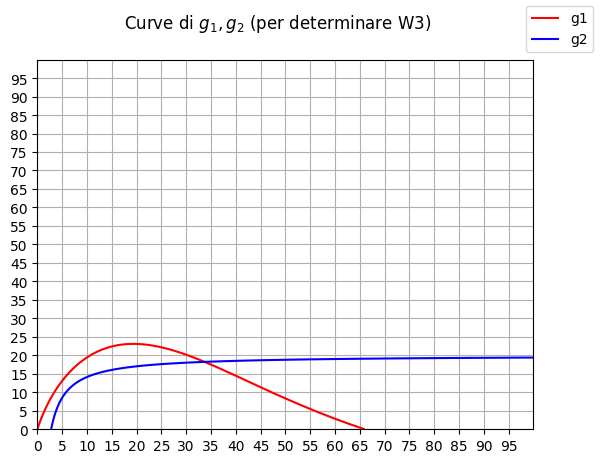

W2 (coesistenza positiva): x=33.70503694844591, y=18.230236966012498
	LAS: No
	GAS: No


In [317]:
# 0: caso in cui W2 è GAS

parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

for i, data_0 in enumerate([(8,2), (2, 3), (8, 5), (5, 7), (15, 10)]):
    x, y = data_0
    simulate(x, y, 50, **parameters, name=f"0_{i}")

check_stability(**parameters)

W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=66.0, y=0
	LAS: No
	GAS: Yes


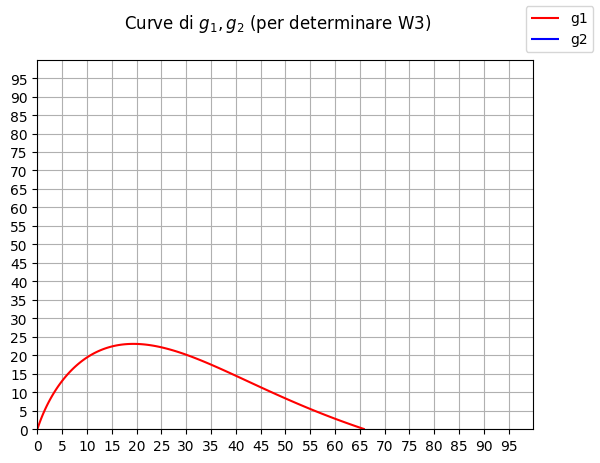

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.


In [318]:
# 1: caso in cui W1 è globalmente attrattivo
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.2,
    'sigma': 0.5,
    'psi': 0.01,
}

initial_points = [(2, 3), (10, 2), (8, 5), (7,7), (15, 12)]

for i, data_0 in enumerate(initial_points):
    x, y = data_0
    simulate(x, y, 100, **parameters, name=f"1_{i}")

check_stability(**parameters)

W0 (estinzione): x=0, y=0
	LAS: Yes
	GAS: No
W2 non esiste


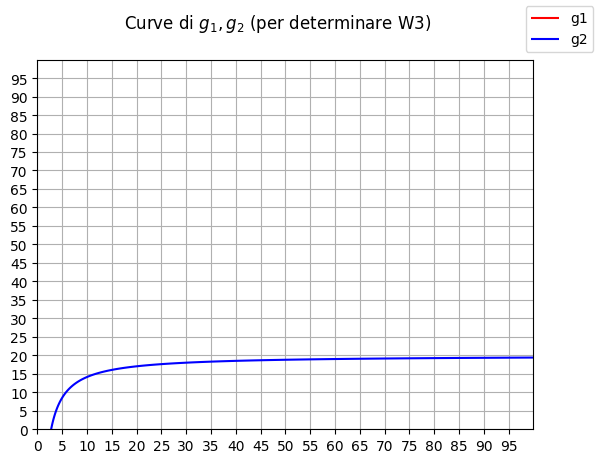

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.


In [319]:
# 2: caso in cui W0 è globalmnte attrattivo
parameters = {
    'r': 0.002,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

initial_points = [(2, 3), (10, 2), (8, 5), (7,7), (15, 12)]

check_stability(**parameters)

for i, data_0 in enumerate(initial_points):
    x, y = data_0
    simulate(x, y, 15, **parameters, name=f"2_{i}")

In [320]:
# 3: soluzioni periodiche

params_1 = {
    'r' : 1.2,
    'f' : 0.03,
    'a' : 0.02,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
    'solver': 'RK45'

}

params_2 = {
    'r': 2,
    'f': 0.5,
    'a': 0.02,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
    'solver': 'RK45'
}

params_3 = {
    'r': 2,
    'f': 0.03,
    'a': 0.4,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
    'solver': 'RK45'

}

simulate(5, 7, 1500, **params_1, name="3_0")
simulate(5, 7, 1500, **params_2, name="3_1")
simulate(5, 7, 1500, **params_3, name="3_2")


In [321]:
# 4. modificare k, epsilon
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

simulate(5, 7, 100, **parameters, k=0.03, eps=0.01, name="4_0")
simulate(5, 7, 100, **parameters, k=0.0003, eps = 0.01, name="4_1")
simulate(5, 7, 1500, **parameters, k=0.03, eps=0.001, name="4_2")


W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=6600.000000000001, y=0
	LAS: No
	GAS: Yes


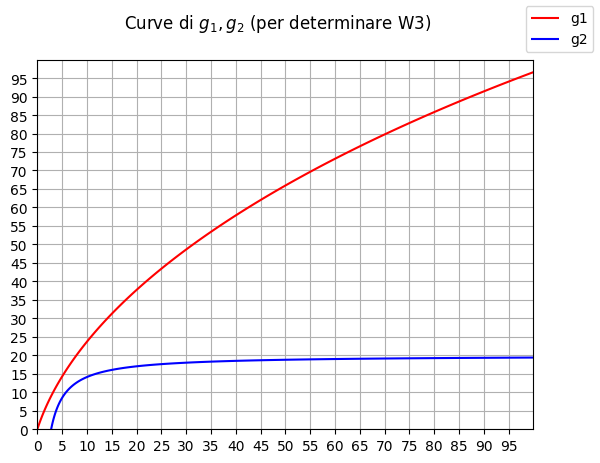

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.


In [322]:
check_stability(**parameters, k=0.0003, eps=0.01)

In [323]:
# 5: modificare e

parameters = {
    'r': 2,
    'beta': 0.5,
    'm': 0.1,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

for i, e_ in enumerate([0.005, 0.4, 0.7]):
    simulate(5, 7, 500, **parameters, e=e_, name=f"5_{i}")

In [111]:
# 6: modificare m

parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

for i, m_ in enumerate([0.1, 0.25, 0.9]):
    simulate(5, 7, 80, **parameters, m=m_, name=f"6_{i}")

### Grafici
Proponiamo i risultati disegnando i grafichetti

In [112]:
def create_graphs(number: int, mult: int, add: int = 0):
    # creo grafici di un esperimento
    # number: numero dell'esperimento
    # mult: di solito gli esperimenti coinvolgono più simulazioni simultanee, quindi dire quanti sono le simulazioni...
    # add: serve solo se voglio prendere una parte specifica dell'esperimento
    
    data = []

    # carico dati salvati in file
    for i in range(mult):
        try:
            data.append(np.loadtxt(f"./data/{number}_{i}.csv", delimiter=','))
        except:
            raise Exception("Parametri in configurazione invalidi!!!")

    # definisco colori
    markers = ['r', 'g', 'b', 'y', 'k']

    # canvas
    fig, axes = plt.subplots(1, 2, figsize = (14, 6))
    fig.suptitle(f"Experiment {number}")

    ax1 = axes[0]
    ax2 = axes[1]

    # primo plot: time series
    for i in range(add, mult):
        ax1.plot(data[i][ :, 0], data[i][ :, 1], markers[i])
        ax1.plot(data[i][ :, 0], data[i][ :, 2], f"{markers[i]}--")

    ax1.set_title(f'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)')
    ax1.set_xlabel('t')
    ax1.set_ylabel('size')
    ax1.grid()

    # secondo plot: fasi
    for i in range(add, mult):
        ax2.plot(data[i][ :, 1], data[i][ :, 2], markers[i])

    ax2.set_title(f'Phase Diagram')
    ax2.set_xlabel('preys')
    ax2.set_ylabel('predators')
    ax2.grid()

    # show!
    plt.show()

    return

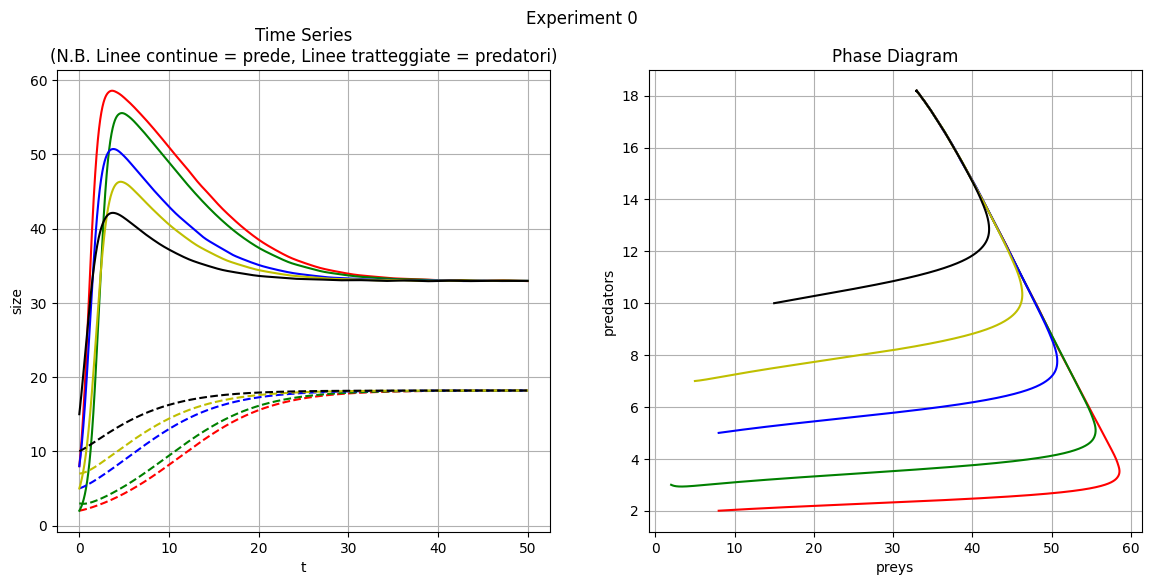

In [113]:
create_graphs(0, 5)

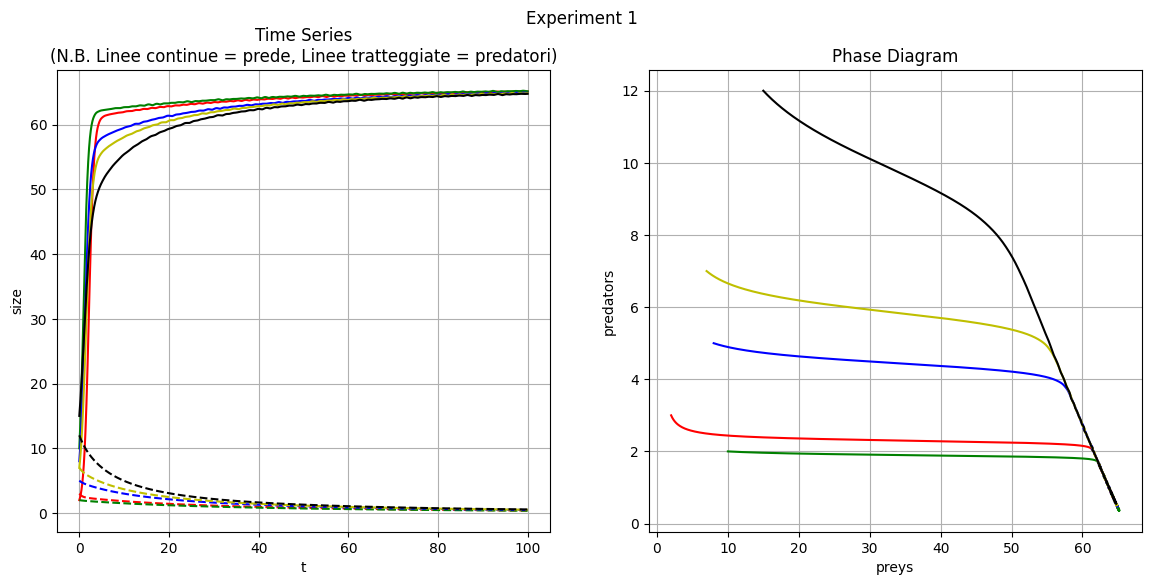

In [114]:
create_graphs(1, 5)

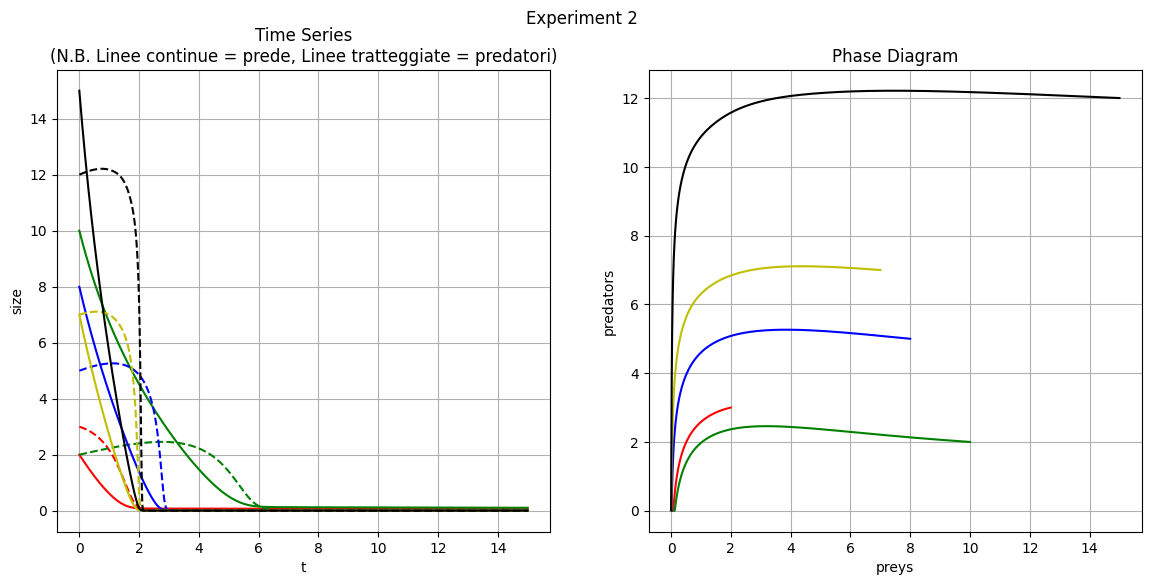

In [115]:
create_graphs(2,5)

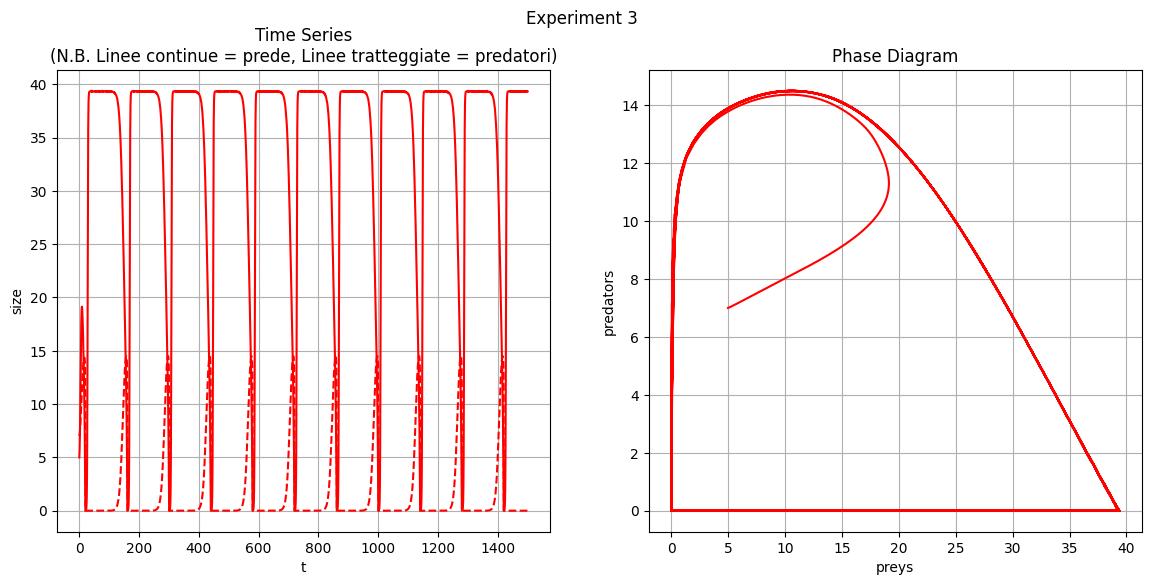

In [116]:
create_graphs(3, 1)

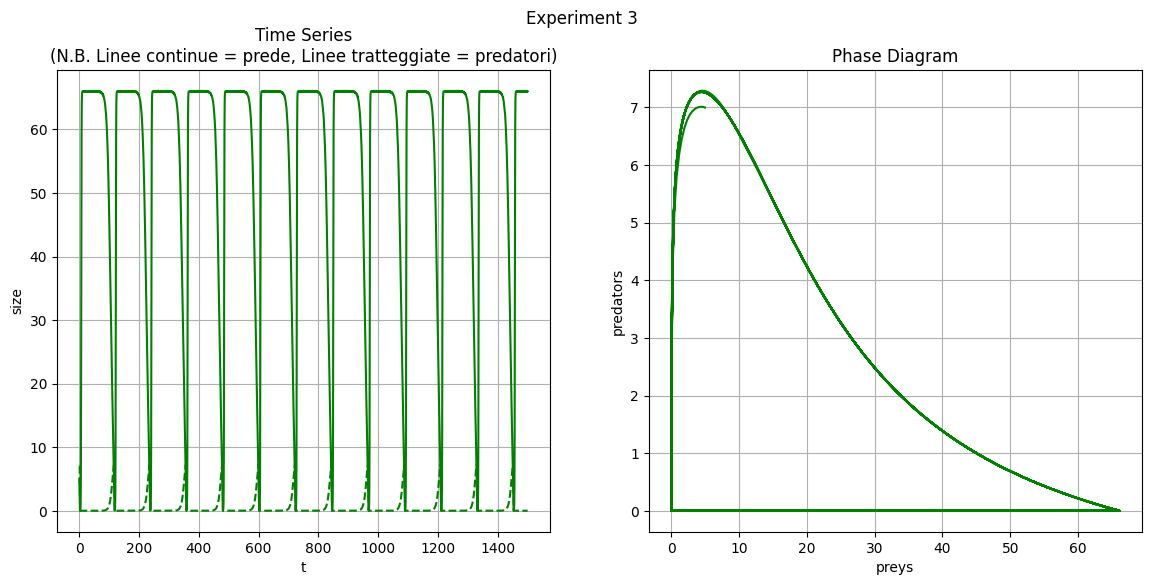

In [117]:
create_graphs(3, 2, 1)

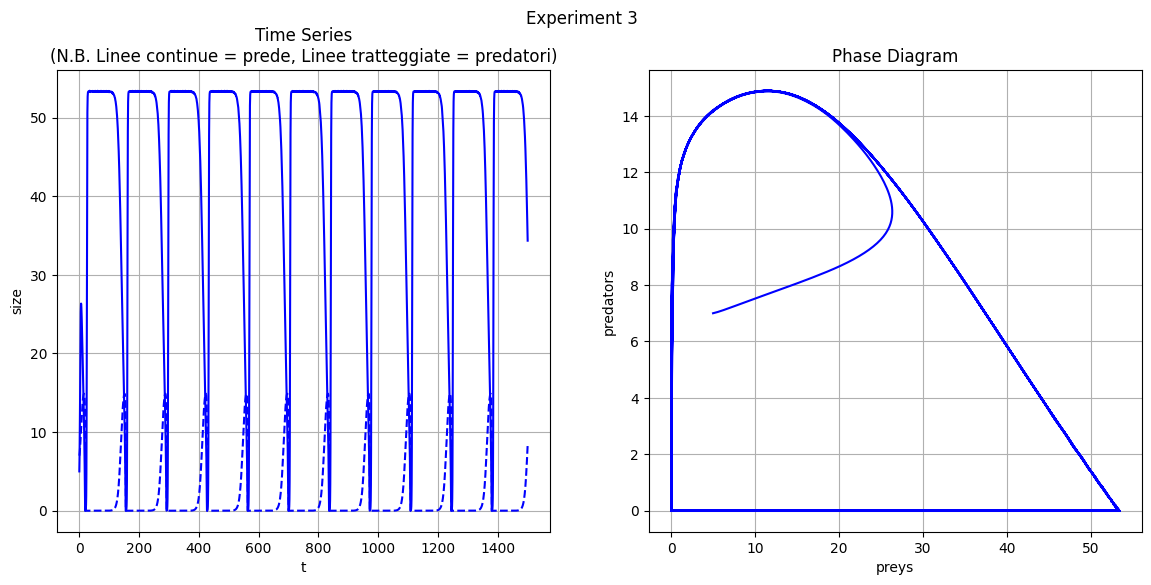

In [118]:
create_graphs(3, 3, 2)

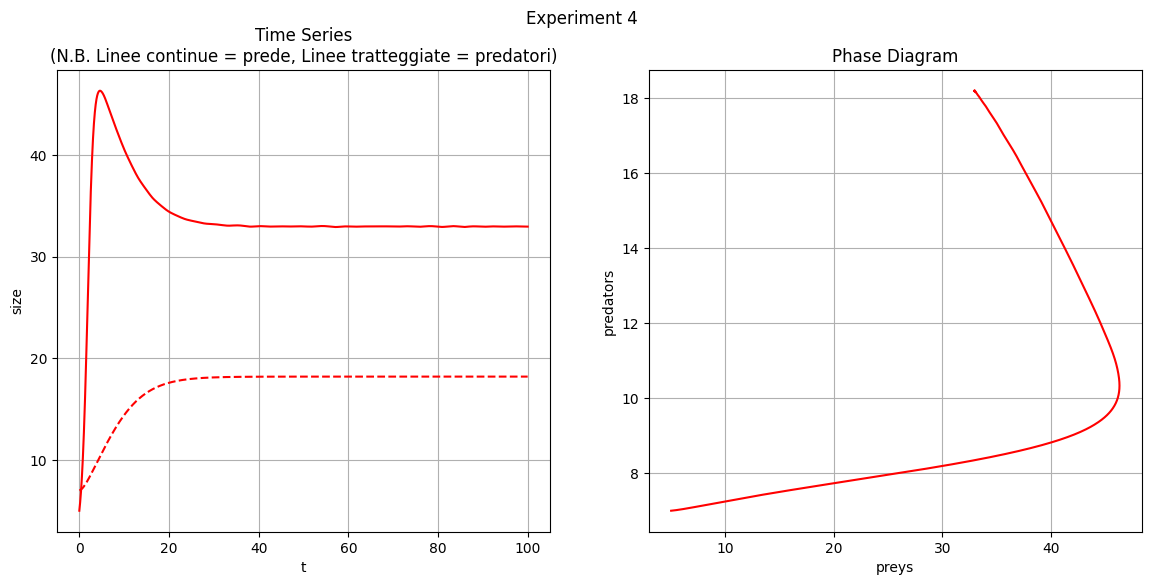

In [119]:
create_graphs(4, 1)

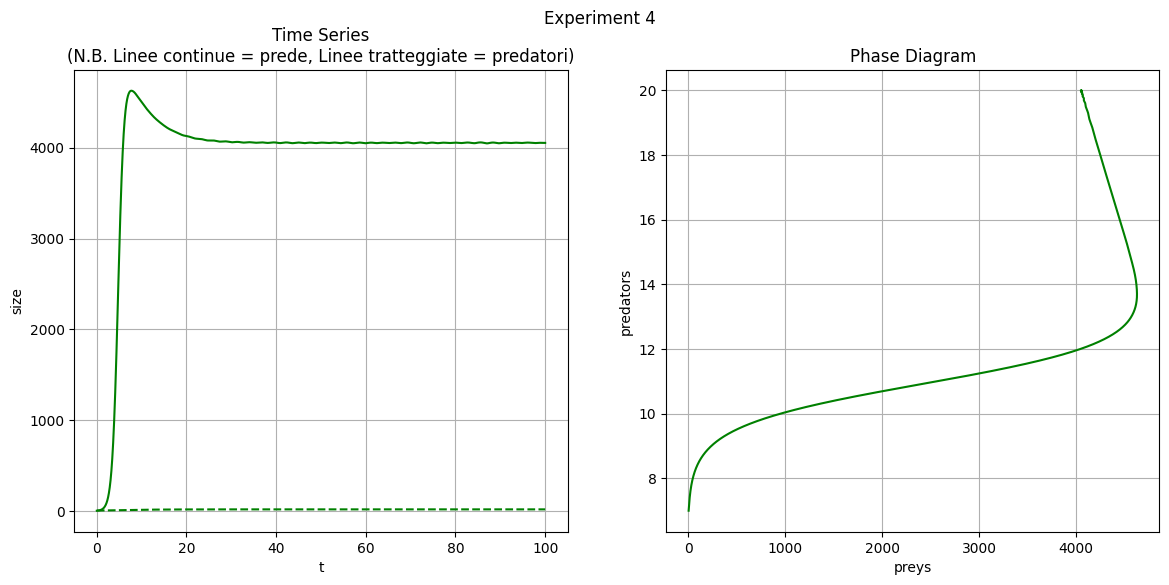

In [120]:
create_graphs(4, 2, 1)

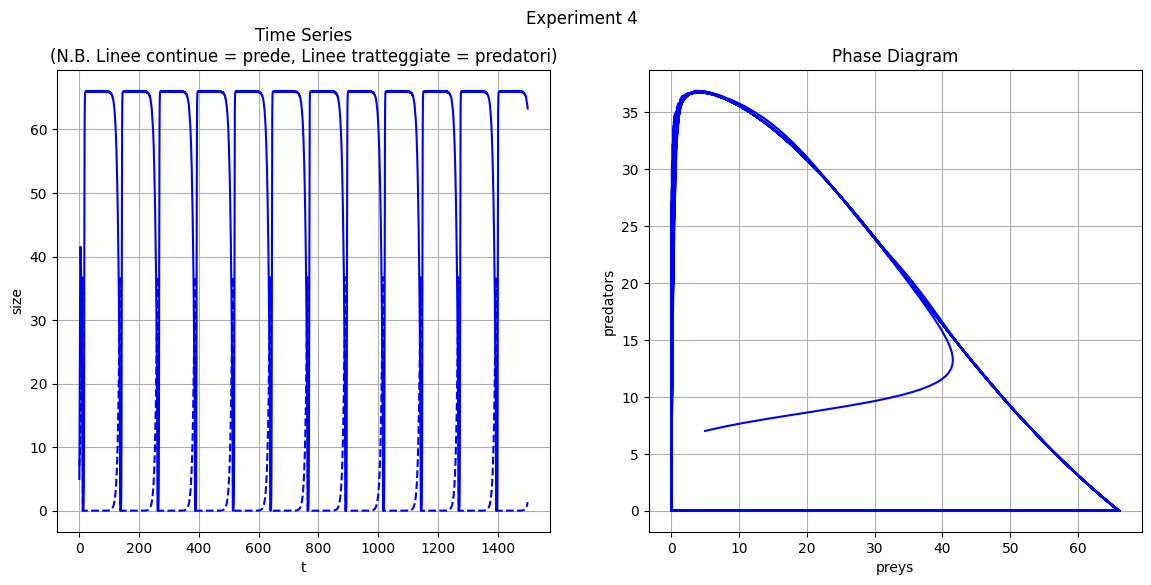

In [121]:
create_graphs(4, 3, 2)

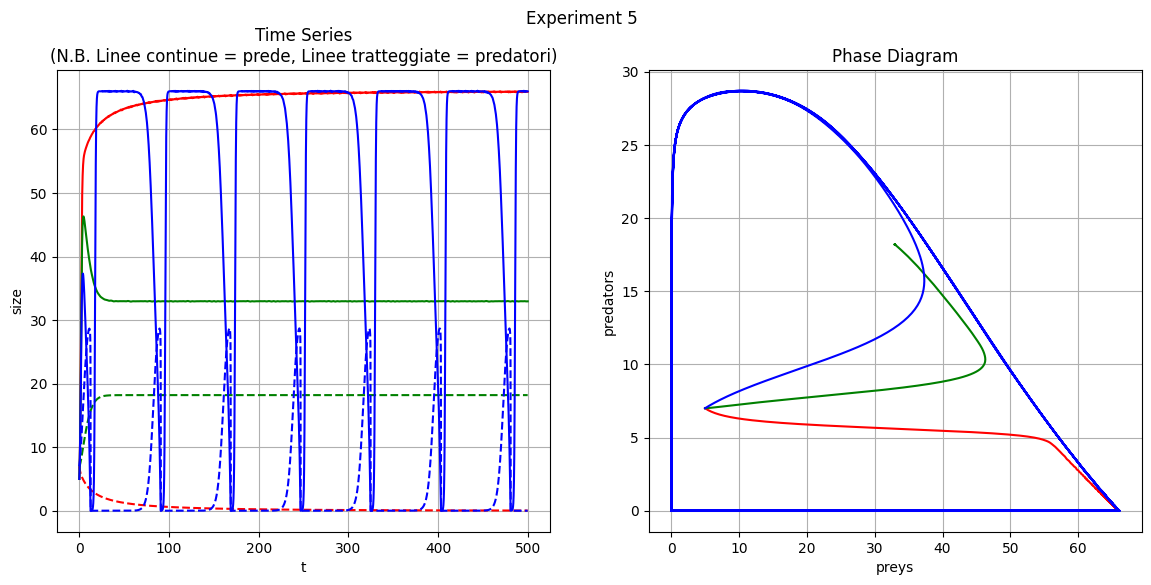

In [122]:
create_graphs(5, 3)

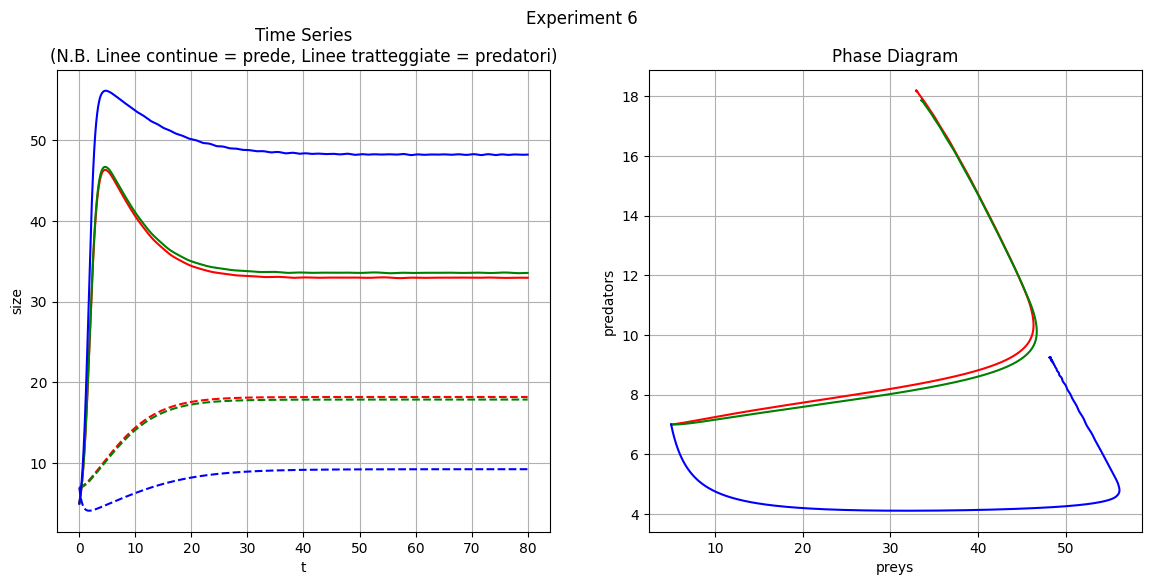

In [123]:
create_graphs(6, 3)

### Animazioni
Aggiuntivamente, ho creato alcune animazioni per dare un'idea migliore delle simulazioni (anche per flexare)

In [124]:
# animate time diagram
# animate the phase diagram

def animate_plots(number: int, mult: int, add: int = 0, multiplier: int = 30):
    # creo grafici di un esperimento
    # number: numero dell'esperimento
    # mult: di solito gli esperimenti coinvolgono più simulazioni simultanee, quindi dire quanti sono le simulazioni...
    # add: serve solo se voglio prendere una parte specifica dell'esperimento
    # multiplier: serve per rendere il rendering più veloce, ossia skippare alcuni dati (sennò il mio pc ci mette decenni...)
    
    data = []

    # carico dati salvati in file
    for i in range(mult):
        try:
            data.append(np.loadtxt(f"./data/{number}_{i}.csv", delimiter=','))
        except:
            raise Exception("Parametri in configurazione invalidi!!!")
            

    data = np.array(data)

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    fig.suptitle(f"Experiment {number}")


    # time series
    ax1 = axes[0]
    ax2 = axes[1]

    prey_curves = []
    predator_curves = []

    markers = ['r', 'b', 'y', 'g', 'k']

    for i in range(add, mult):
        prey_curves.append(ax1.plot(data[i][0, 0], data[i][0, 1], markers[i]))
        predator_curves.append(ax1.plot(data[i][0, 0], data[i][0, 2], f"{markers[i]}--"))

    ax1.set_title(f"Time Series")
    ax1.grid()
    ax1.set_xlabel("t")
    ax1.set_ylabel("amount")

    ax1.set_xlim(0, data[0, -1, 0] - 1)
    ax1.set_ylim(np.min(data[:, :, [1,2]]) - 2, np.max(data[:, :, [1,2]]) + 2)

    phase_curves = []
    phase_dots = []

    dots = ['ro', 'bo', 'yo', 'go', 'ko']

    for i in range(add, mult):
        phase_curves.append(ax2.plot(data[i][0, 1], data[i][0, 2], markers[i]))
        phase_dots.append(ax2.plot(data[i][0, 1], data[i][0, 2], dots[i]))

    ax2.set_title(f"Phase Diagram")
    ax2.grid()
    ax2.set_xlabel("preys")
    ax2.set_ylabel("predators")

    ax2.set_xlim(np.min(data[:, :, [1]]) - 3, np.max(data[:, :, [1]]) + 3)
    ax2.set_ylim(np.min(data[:, :, [2]]) - 3, np.max(data[:, :, [2]]) + 3) # tutti questi -1, +1 per rendere più visibile gli estremi


    def animate(j):
        for i in range(mult-add):
            prey = prey_curves[i][0]
            predator = predator_curves[i][0]

            prey.set_data(data[i][:j*multiplier, 0], data[i][:j*multiplier, 1])
            predator.set_data(data[i][:j*multiplier, 0], data[i][:j*multiplier, 2])

        for i in range(mult-add):
            phase_curve = phase_curves[i][0]
            phase_dot = phase_dots[i][0]

            phase_curve.set_data(data[i][:j*multiplier, 1], data[i][:j*multiplier, 2])
            phase_dot.set_data([data[i][j*multiplier, 1]], [data[i][j*multiplier, 2]])

        return fig

    ani = animation.FuncAnimation(fig, animate, frames=len(data[i][:, 0])//multiplier)
    ffmpeg_writer = animation.FFMpegWriter(fps=30)
    ani.save(f'./videos/{number}_{add}.mp4', writer=ffmpeg_writer)

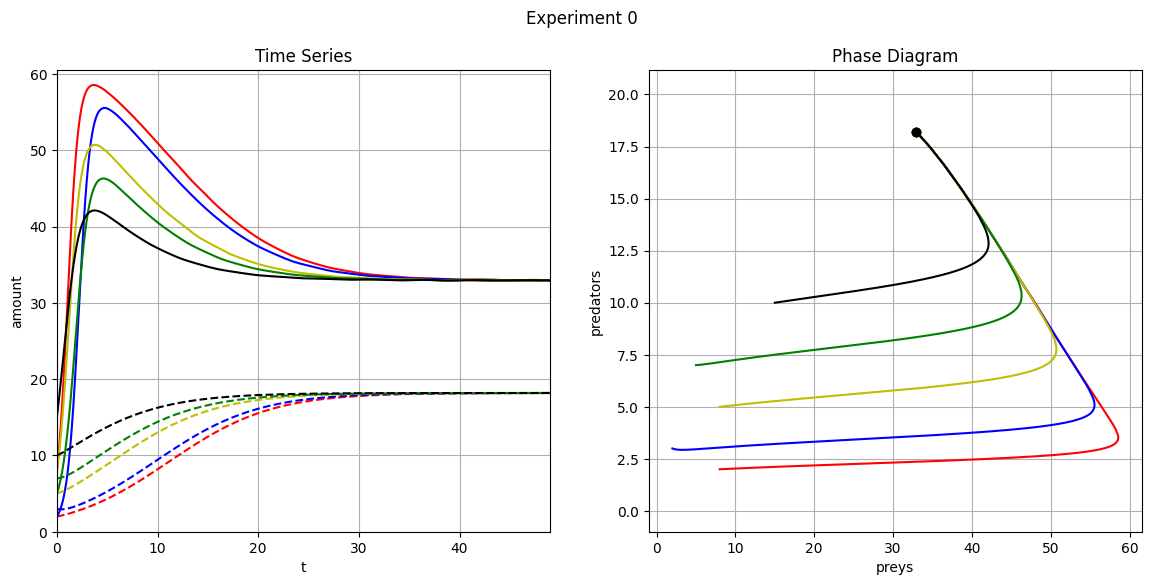

In [97]:
animate_plots(0, 5, 0, 30)

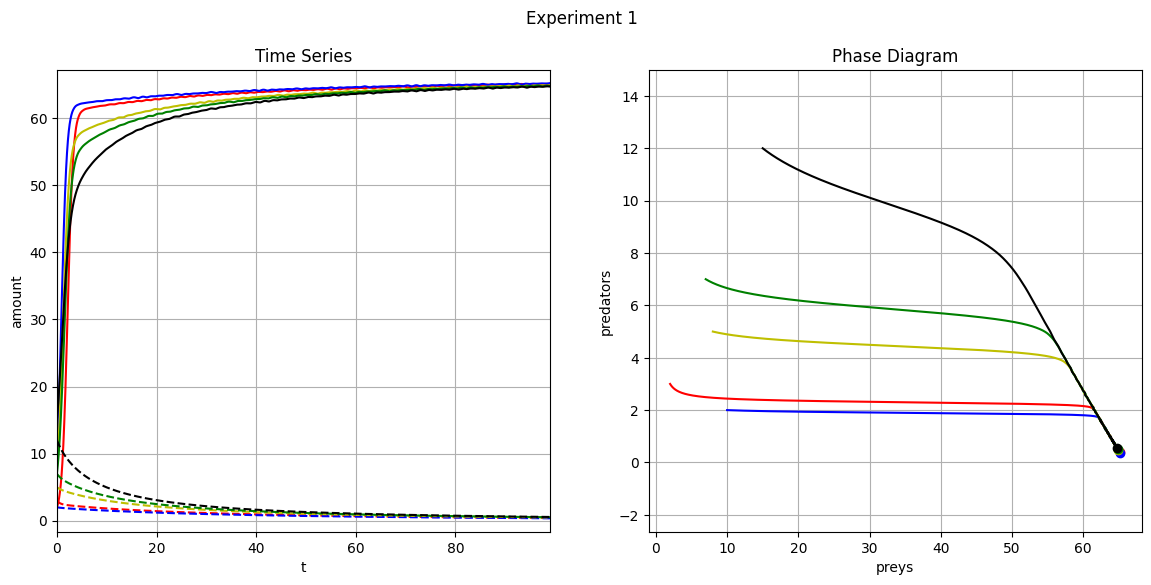

In [100]:
animate_plots(1, 5, 0, 30)

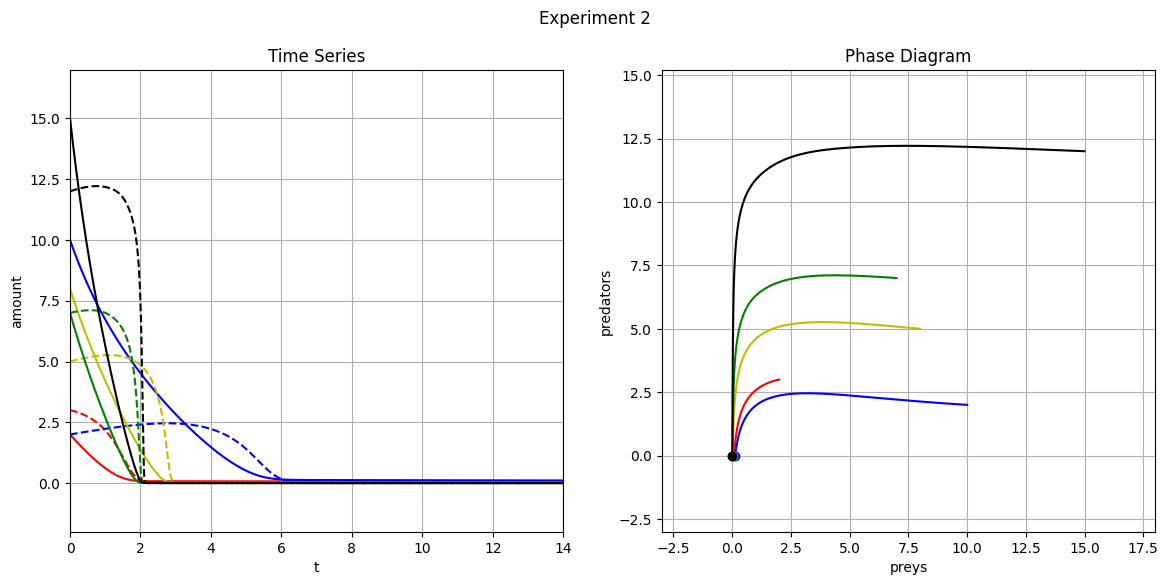

In [101]:
animate_plots(2, 5, 0, 30)

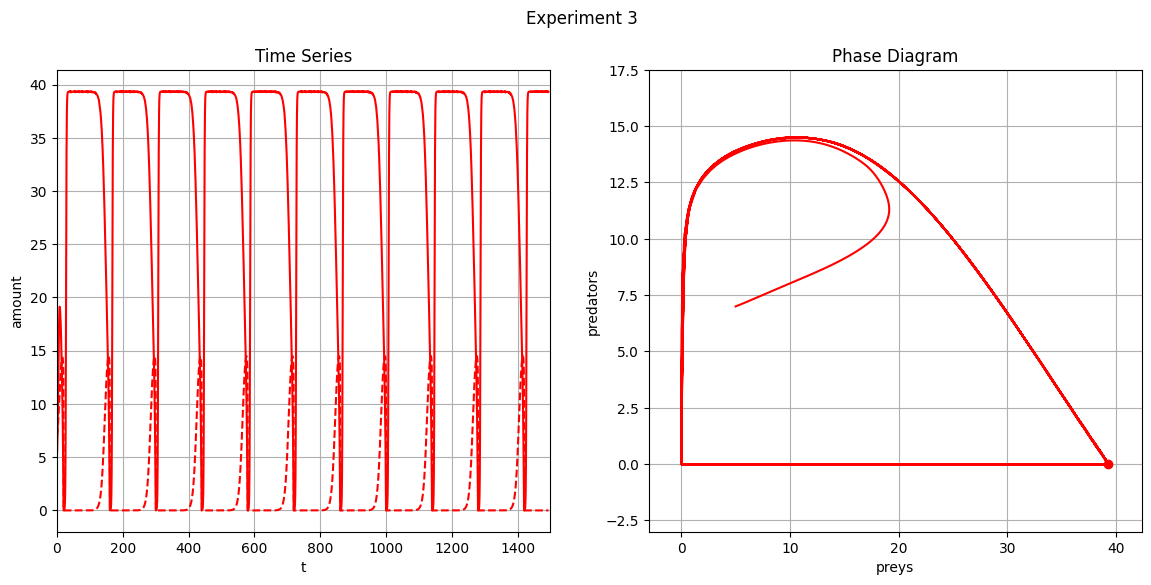

In [102]:
animate_plots(3, 1, 0, 30)

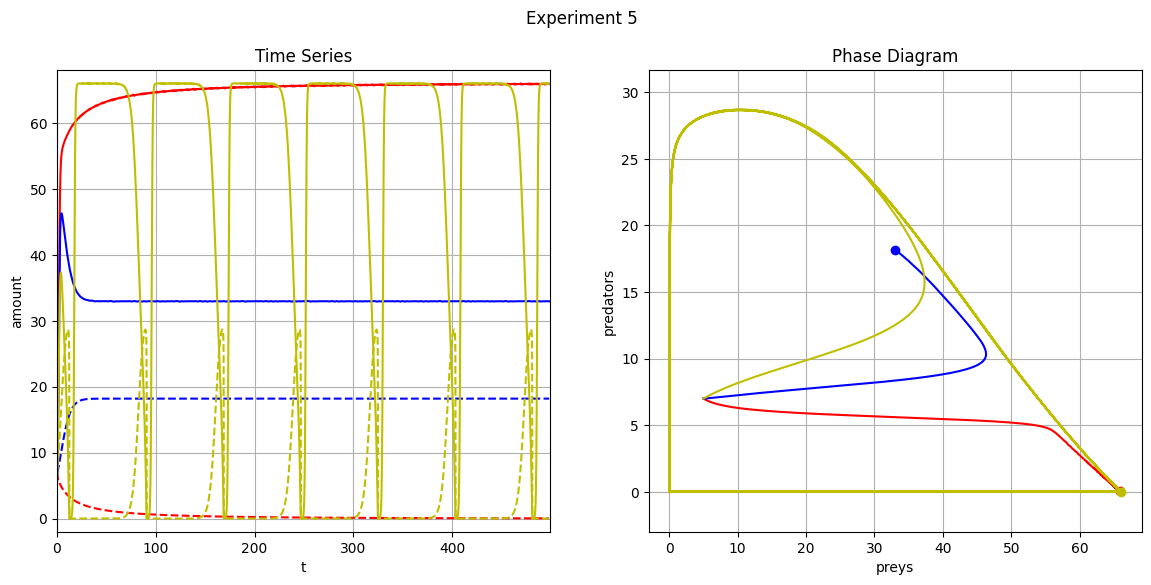

In [103]:
animate_plots(5, 3, 0, 30)

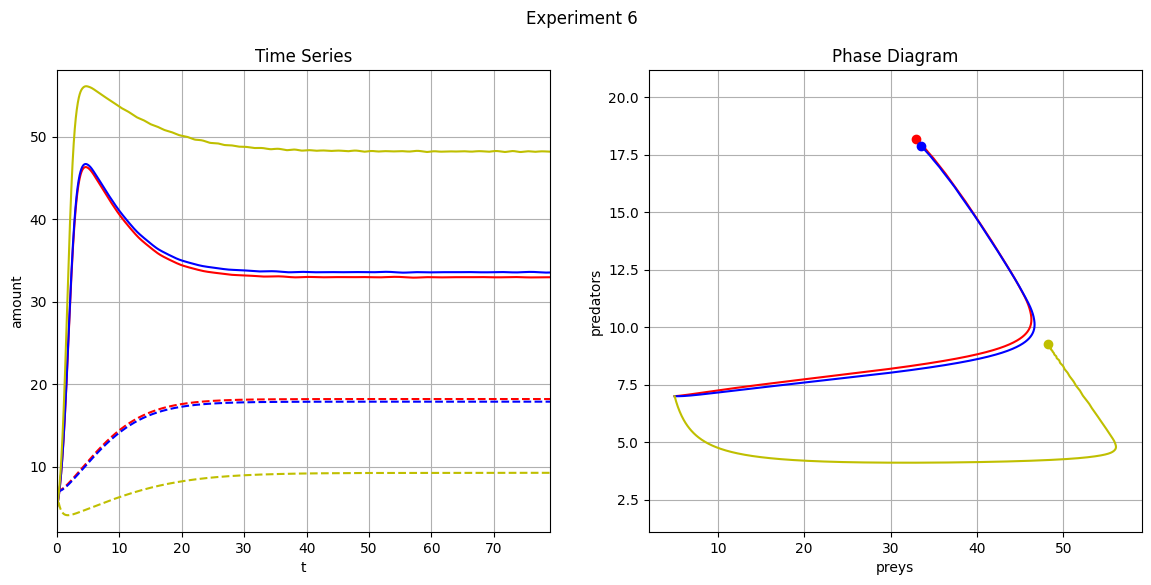

In [125]:
animate_plots(6, 3, 0, 30)

## Parte 3: Problemi con il Paper

### Non replicabilità dei risultati: Punto d'Equilibrio di Coesistenza

### Non replicabilità dei risultati: Cicli Limite

### Non replicabilità dei risultati: Test per determinare stabilità dei punti d'equilibrio

## Parte 4: Ulteriori sperimentazioni

### Nuovo strumento: disegno del campo vettoriale

Ho ritenuto che sarebbe stato molto utile implementare una funzione che disegni il campo vettoriale dell'ODE, ovvero effettuare un'osservazione simile a quella fatta quando abbiamo studiato i modelli di competizione.

In questo modo, sarebbe stato diventato più facile illustrare la stabilità locale/globale dei punti d'equilibrio.

In [131]:
def sub_model(x, y, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi):
    # tolte le x,y per rendere meglio la rappresentazione grafica; tanto stiamo cercando soluzioni positive...
    return (
        (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x,
        ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y
    )

def plot_vector_field(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, xlim: Tuple[float, float], ylim: Tuple[float, float], delta: float = 0.5, scale: float = 1):
    # Calcola il zero degli isoclini, calcolando i campi vettoriali

    xmin, xmax = xlim 
    ymin, ymax = ylim 

    x = np.arange(xmin, xmax, delta)
    y = np.arange(ymin, ymax, delta)
    X, Y = np.meshgrid(x, y)

    dX, dY = sub_model(X, Y, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi)

    fig, ax = plt.subplots( figsize = (15, 7.5) )

    fig.suptitle("Campo Vettoriale del modello")
    
    ax.quiver(X, Y, dX, dY, scale)
    ax.grid(True)

    plt.show()

    return fig, ax



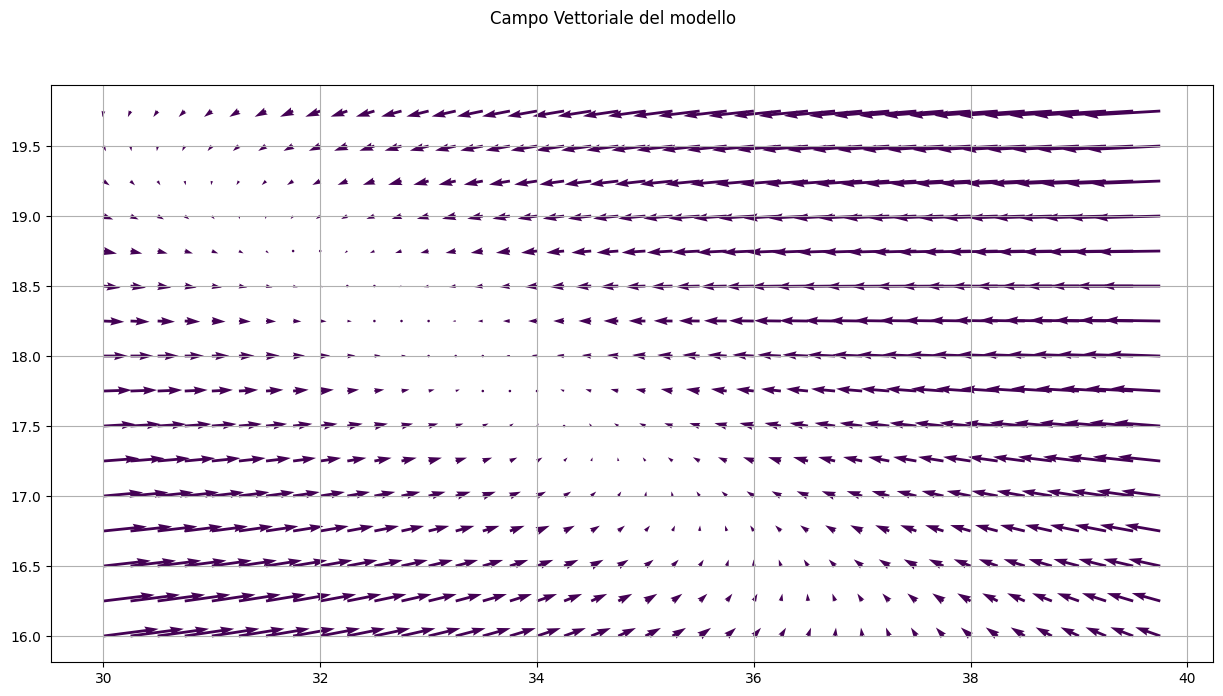

(<Figure size 1500x750 with 1 Axes>, <Axes: >)

In [145]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

plot_vector_field(xlim = (30.0, 40.0), ylim = (16.0, 20.0), delta=0.25, **parameters)

### Correzione dell'algoritmo per trovare il punto d'equilibrio di coesistenza

Per correggere l'algoritmo che trova i punti d'equilibrio (in particolare quello di coesistenza), abbiamo modificato la definizione degli isoclini in un modo tale da riflettere la definizione del modello in maniera più accurata. In questo caso, è stato sufficiente prendere la definizione del modello e togliere il fattore $x$ (o $y$).

In [146]:

def find_PIEP(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver = (50,50)): 
    # W2: PIEP
    def g1(vec):
        x, y = vec
        return (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x

    def g2(vec):
        x,y = vec
        return ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y
    

    ## curve g1=0, g2=0 per aiutare l'user a determinare una sua intersezione approssimativa (così da aiutare il solver...)
    delta = 0.025
    xrange = np.arange(0, 100, delta)
    yrange = np.arange(0, 100, delta)

    X, Y = np.meshgrid(xrange, yrange)


    fig, ax = plt.subplots()

    fig.suptitle("Curve di $g_1, g_2$ (per determinare W3)")
    ax.grid(True)
    ax.set_xticks(np.arange(0, 100, 5))
    ax.set_yticks(np.arange(0, 100, 5))

    cs1 = ax.contour(X, Y, g1([X, Y]), [0], colors='r')
    cs2= ax.contour(X, Y, g2([X, Y]), [0], colors='b')

    artists1, _ = cs1.legend_elements()
    artists2, _ = cs2.legend_elements()


    fig.legend(artists1 + artists2, ['g1', 'g2'])

    plt.show()
    
    sol = fsolve(lambda vec: (g1(vec), g2(vec)), init_solver)

    x2, y2 = sol
    

    if x2 < 0 or y2 < 0:
        print("Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)")
        print("N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.")

    else:
        print(f"W2 (coesistenza positiva): x={x2}, y={y2}")


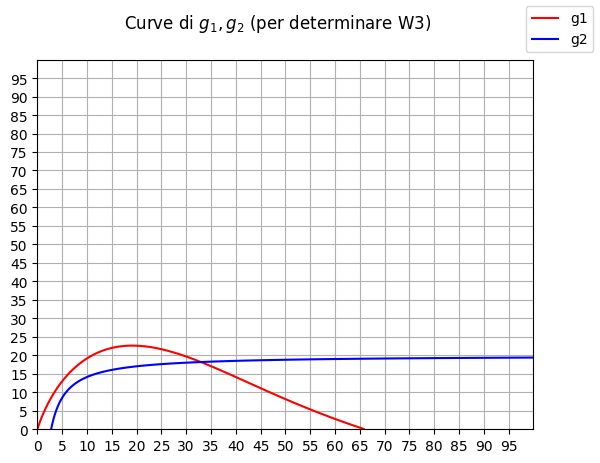

W2 (coesistenza positiva): x=32.95651821324798, y=18.190369110171137


In [150]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

find_PIEP(**parameters)

### boh

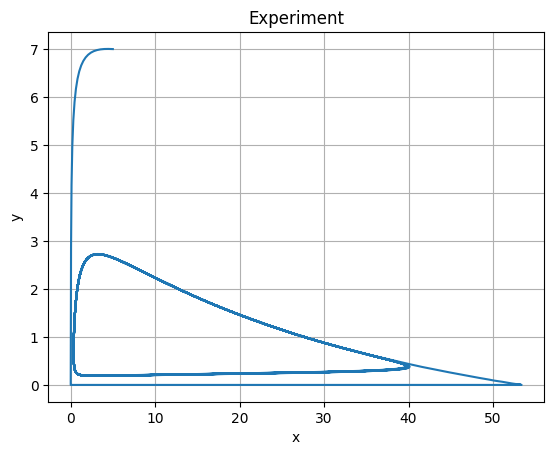

In [ ]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.5,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.4,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

simulate(5, 7, 500, **parameters, name=f"xxx_1", solver='RK45')

data = (np.loadtxt(f"./data/xxx_1.csv", delimiter=','))

plt.plot(data[ :, 1], data[ :, 2])

plt.title('Experiment')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

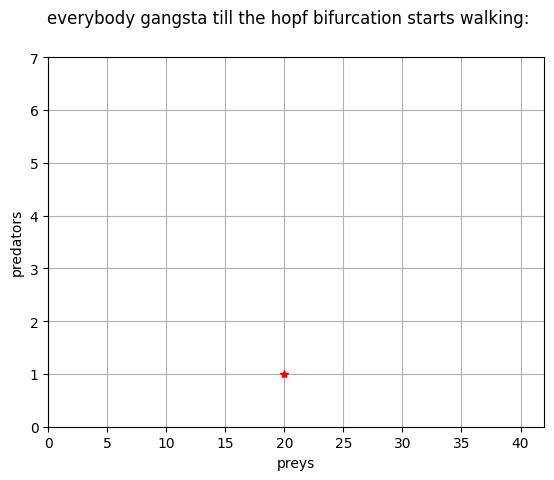

In [49]:
# animate the phase diagram
fig, ax = plt.subplots()

phase_curve, = ax.plot(data[0, 1], data[0, 2], 'r')
phase_dot, = ax.plot(data[0, 1], data[0, 2], 'r*')

fig.suptitle("everybody gangsta till the hopf bifurcation starts walking:")
ax.grid()
ax.set_xlim(0, 42)
ax.set_ylim(0, 7)
ax.set_xlabel("preys")
ax.set_ylabel("predators")

k = 30

def animate(j):
    phase_curve.set_data(data[:j*k, 1], data[:j*k, 2])
    phase_dot.set_data([data[j*k, 1]], [data[j*k, 2]])

    return fig

ani = animation.FuncAnimation(fig, animate, frames=len(data[:, 0])//k)
ffmpeg_writer = animation.FFMpegWriter(fps=30)
ani.save('./videos/nulla di serio.mp4', writer=ffmpeg_writer)